# Fifa Prediction model

Each training example will be a (22,9) matrix. Each row is a player, the first 11 rows are players from the home team while the last 11 rows are players from the away team. For each player, the following details are used:

1. age
2. is forward
3. is mid fielder
4. is defense
5. is goalkeeper
6. number tournaments
7. appearances
8. goals
9. average time per team

This matrix will be passed to the first layer of the neural network that should predict the 'quality' of each player in the team. There will be a ReLU activation for this network. This will be done by doing:

$$
p = xw^T + b \\
ap = max(0, p)
$$

The output of this will be a (22, 1) matrix. This will then be passed to the team wins prediction portion of the network. This has 1 layer with 121 units with softmax activation as shown below:

$$
L = 1 \\
n^{[1]} = 2 \\
z = apw + b \\
y = softmax(z)
$$

The goal is to get a model that surpasses the following benchmarks:
- 75.42% accuracy on predicting a win
- 18% accuracy for predicting exact scores

In [512]:
# Imports
import numpy as np
import numpy.typing as npt
from sklearn.model_selection import train_test_split
import math
import matplotlib.pyplot as plt
import time

In [513]:
def f_x(
    players: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float
):
    """ 
    Function that will do a forward pass for a single training example in the example above.
    
    Args:
        players (ndarray) - a (22,9) numpy array with 9 features for 22 players from the home and away team
        w_p (ndarray) - a (1,9) numpy array with weights for player predictions
        b_p (scalar) - bias for player quality prediction
        w_t (ndarray) - a (121, 22) numpy array with the weights for the team score prediction
        b_t (scalar) - bias for the team score prediction
        
    Returns:
        scores (ndarray) - a (121,1) numpy array with probability of each of the score distributions
        z_t (ndarray) - cached z_t value
        a_p (ndarray) - cached a_t value,
        z_p (ndarray) - cached z_p value
    """
    z_p = np.matmul(players, w_p.T) + b_p
    a_p = np.maximum(0, z_p)
    z_t = np.matmul(w_t, a_p) + b_t
    shifted_logits = z_t - np.max(z_t, axis=0, keepdims=True)
    e_zi = np.exp(shifted_logits)
    a_t = e_zi / np.sum(e_zi, axis=0, keepdims=True)
    return (a_t, z_t, a_p, z_p)
    

In [514]:
# Forward pass is working
players_1 = np.ones((1, 9))
players_1 = np.tile(players_1, (22, 1))
w_p = np.ones((1, 9))
b_p = 0
w_t = np.ones((121, 22))
b_t = 0
result_1 = f_x(
    players_1,
    w_p,
    b_p,
    w_t,
    b_t
)
print(result_1[0])

[[0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00

In [515]:
def L(y_pred, y):
    """
    Returns the means squared error of a single example
    
    Args:
        y_pred (ndarray) - predicted home away goal scores
        y (ndarray) - actual home away goal scores
        
    Returns:
        error (scalar) - mean squared error loss
    """
    loss = np.where(y == 1, -np.log(y_pred + 1e-15), 0) # Adding by a small number to prevent trying to get log of 0
    return np.sum(loss)

In [516]:
print(L(np.array([0.778,0.232]), np.array([1,0])))

0.25102875480374415


In [517]:

def predict(
    X: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float,
):
    """ 
    Make prediction for all of the examples in the passed dataset (Vectorized implementation)
    
    Args:
        X (ndarray) - a (m,22,9) array with m examples
        w_p (ndarray) - weights for the player section of neural network
        b_p (scalar) - bias for the player section of neural network
        w_t (ndarray) - weights for team section of neural network
        b_t (scalar) - bias for team section of neural network
        
    Returns:
        Y_pred (ndarray) - a (m, 121, 1) array with prediction of all examples in X
        Z_t(ndarray) - cached Z_t value
        A_p (ndarray) - cached A_p value
        Z_p (ndarray) - cached A_p value
    """    
    Z_p = np.matmul(X, w_p.T) + b_p
    A_p = np.maximum(0, Z_p).squeeze(-1) # Reducing dimensions to allow operations
    Z_t = np.matmul(A_p, w_t.T) + b_t
    shifted_logits = Z_t - np.max(Z_t, axis=1, keepdims=True)
    e_zi = np.exp(shifted_logits)
    A_t = e_zi / np.sum(e_zi, axis=1, keepdims=True)
    
    # Expanding dimensions to match expected dimenstions in data
    returned_A_t = np.expand_dims(A_t, axis=-1)
    returned_A_p = np.expand_dims(A_p, axis=-1)
    returned_Z_t = np.expand_dims(Z_t, axis=-1)
    
    return (returned_A_t, returned_Z_t, returned_A_p, Z_p)

In [518]:
def calculate_gradients(
    X: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float,
    Y: npt.NDArray
):
    """ 
    Function to calculate the gradients used in gradient descent
    
    Args:
        X (ndarray) - a (m,22,9) array with m training examples
        Y (ndarray) - a (m, 121, 1) array with labels for m training examples
        w_p (ndarray) - weights for the player section of neural network
        b_p (scalar) - bias for the player section of neural network
        w_t (ndarray) - weights for team section of neural network
        b_t (scalar) - bias for team section of neural network
        
    Returns:
        gradients (list) - list of gradients of parameters
    """
    # da_t_i = 2 * (y_pred_i - y_i)
    m = X.shape[0]
    
    (Y_pred, Z_t, A_p, Z_p) = predict(
        X=X,
        w_p=w_p,
        w_t=w_t,
        b_p=b_p,
        b_t=b_t
    )

    # dZ_t = (Y_pred - Y).squeeze(-1) # Remove final dimension so that next operations can proceed well
    dZ_t = Y_pred - Y
    # dw_t = np.zeros((121, 22)) if m == 0 else (1 / m) * A_p.T * dZ_t
    dw_t = np.zeros((121, 22)) if m == 0 else np.sum(
        np.matmul(dZ_t, A_p.transpose(0, 2, 1)), axis=0
    ) / m
    db_t = 0 if m == 0 else np.sum(dZ_t) / m
    dA_p = np.matmul(w_t.T, dZ_t)
    dZ_p = np.where(Z_p < 0, 0, dA_p)
    # dw_p = np.zeros((1, 9)) if m == 0 else (1 / m) * np.matmul(dZ_p.T, X)
    # dw_p = np.zeros((1, 9)) if m == 0 else np.sum(np.matmul(dZ_p.transpose(0, 2, 1), X), axis=0) / m
    # dw_p = np.zeros((1, 9)) if m == 0 else np.sum(
    #     np.matmul(dZ_p, X.transpose(0, 2, 1)), axis=0
    # ) / m
    dw_p = np.zeros((1, 9)) if m == 0 else (dZ_p.transpose(0, 2, 1) @ X).sum(axis=0) / m
    db_p = 0 if m == 0 else np.sum(dZ_p) / m
    J = 0 if m == 0 else L(Y_pred, Y) / m
    return (dw_p, db_p, dw_t, db_t, J)

def old_calculate_gradient(
    X: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float,
    Y: npt.NDArray
):
    """ 
    Function to calculate the gradients used in gradient descent
    
    Args:
        X (ndarray) - a (m,22,9) array with m training examples
        Y (ndarray) - a (m, 121, 1) array with labels for m training examples
        w_p (ndarray) - weights for the player section of neural network
        b_p (scalar) - bias for the player section of neural network
        w_t (ndarray) - weights for team section of neural network
        b_t (scalar) - bias for team section of neural network
        
    Returns:
        gradients (list) - list of gradients of parameters
    """
    # da_t_i = 2 * (y_pred_i - y_i)
    m = X.shape[0]
    
    dw_t = np.zeros(w_t.shape)
    db_t = 0
    dw_p = np.zeros(w_p.shape)
    db_p = 0
    J = 0
    
    # For each training example
    for i in range(m):
        # Get the prediction
        x_i = X[i]
        y_i = Y[i]
        (y_pred_i, z_t_i, a_p_i, z_p_i) = f_x(
            x_i,
            w_p,
            b_p,
            w_t,
            b_t
        )
        
        
        # Get derivative
        
        dz_t_i = y_pred_i - y_i
        dw_t += a_p_i.T * dz_t_i
        db_t += np.sum(dz_t_i)
        da_p_i = np.matmul(w_t.T, dz_t_i)
        dz_p_i = np.where(z_p_i < 0, 0, da_p_i)
        dw_p += np.matmul(dz_p_i.T, x_i)
        db_p += np.sum(dz_p_i)
        
        # Add loss 
        J += L(y_pred_i, y_i)
        
        
    dw_t /= m
    db_t /= m
    dw_p /= m
    db_p /= m
    J /= m
    return (dw_p, db_p, dw_t, db_t, J)

In [519]:
x_train_1 = np.ones((1, 9))
x_train_1 = np.tile(x_train_1, (22, 1))
w_p = np.ones((1, 9))
b_p = 0
w_t = np.ones((121, 22))
b_t = 0
X_train = np.array([
    x_train_1
])
y_train_1 = np.zeros((121, 1))
y_train_1[0][0] = 1
Y_train = np.array([
    y_train_1
])

old_gradient_descent_test = old_calculate_gradient(
    X=X_train,
    w_p=w_p,
    b_p=b_p,
    w_t=w_t,
    b_t=b_t,
    Y=Y_train,
)

gradients_test = calculate_gradients(
    X_train,
    w_p,
    b_p,
    w_t,
    b_t,
    Y_train
)

In [520]:
# Splitting data into train / cross-validation / test sets
X = np.load("data/players_batch_6_2026-05-25 21:44:14.801126.npy")
Y = np.load("data/results_batch_6_2026-05-25 21:44:14.801174.npy")
X_train, X_mid, Y_train, Y_mid = train_test_split(X, Y, test_size=0.2, random_state=42)
X_cv, X_test, Y_cv, Y_test = train_test_split(X_mid, Y_mid, test_size=0.5, random_state=42)
print(X_train.shape, X_cv.shape, X_test.shape)
print(Y_train.shape, Y_cv.shape, Y_test.shape)

(560, 22, 9) (70, 22, 9) (70, 22, 9)
(560, 121, 1) (70, 121, 1) (70, 121, 1)


In [521]:
# Scale features
mean = np.mean(X_train, axis=(0,1), keepdims=True)
std = np.std(X_train, axis=(0,1), keepdims=True)
std = np.where(std == 0, 1.0, std)

X_train_scaled = (X_train - mean) / std
X_cv_scaled = (X_cv - mean) / std
X_test_scaled = (X_test - mean) / std
print(X_train_scaled.shape)
print(X_cv_scaled.shape)
print(X_test_scaled.shape)

(560, 22, 9)
(70, 22, 9)
(70, 22, 9)


In [522]:
def gradient_descent(
    X: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float,
    Y: npt.NDArray,
    alpha: float,
    num_iters: int,
    J_n: int = 10
):
    """ 
    This function will minimize the cost of the model using gradient descent and return found weights
    
    Args:
        X (ndarray) - a (m, 22, 9) array serving as input to model
        w_p (ndarray) - a (1,9) array with the initial weights of the player section of model
        b_p (scalar) - initial bias for player section of model
        w_t (ndarray) - a (2,22) array with initial weights of the team section of model
        b_t (scalar) - initial bias for team section of model
        Y (ndarray) - a (m, 2, 1) array with target outputs for model
        alpha (scalar) - learning rate
        num_iters (scalar) - number of times to run gradient descent
        J_n (scalar) - interval to store training example
        
    Return:
        w_p (ndarray) - a (1, 9) array that minimizes cost
        b_p (scalar) - bias that minimized cost
        w_t (ndarray) - a (2, 22) array that minimizes cost
        b_t (scalar) - bias that minimizes cost
        Js (list) - list of training costs and epoch at different iterations of training
    """
    Js = []
    for epoch in range(num_iters):
        # Get derivatives
        (dw_p, db_p, dw_t, db_t, J) = calculate_gradients(
            X=X,
            w_p=w_p,
            b_p=b_p,
            w_t=w_t,
            b_t=b_t,
            Y=Y
        )
        
        # Update weights
        w_p = w_p - (alpha * dw_p)
        w_t = w_t - (alpha * dw_t)
        b_p = b_p - (alpha * db_p)
        b_t = b_t - (alpha * db_t)
        
        # Print result
        print(f"Cost at epoch {epoch}/{num_iters} = {J}")
        
        if epoch % J_n == 0 or epoch == num_iters - 1:
            Js.append((epoch, J))
        
    return (w_p, w_t, b_p, b_t, Js)

In [523]:
# Confirm that gradient descent is working
# Get initial weights
start_time = time.perf_counter()
w_t = np.random.rand(121, 22)
w_p = np.random.rand(1, 9)
b_p = 0
b_t = 0

# Run gradient descent
(new_w_p, new_w_t, new_b_p, new_bt, J_train_s) = gradient_descent(
    X=X_train_scaled,
    w_p=w_p,
    w_t=w_t,
    b_p=b_p,
    b_t=b_t,
    Y=Y_train,
    alpha=0.3,
    num_iters=1000
)
stop_time = time.perf_counter()
execution_time = stop_time - start_time
print(f"Training took {execution_time:.6f}s")

Cost at epoch 0/1000 = 7.200142030327065
Cost at epoch 1/1000 = 4.835324971715628


Cost at epoch 2/1000 = 4.625919055702537
Cost at epoch 3/1000 = 4.450286683392248
Cost at epoch 4/1000 = 4.1883138437917085
Cost at epoch 5/1000 = 3.8889179411082524
Cost at epoch 6/1000 = 3.6193454933495945
Cost at epoch 7/1000 = 3.3670494425621027
Cost at epoch 8/1000 = 3.048364528255785
Cost at epoch 9/1000 = 2.75496081616923
Cost at epoch 10/1000 = 2.602833257523993
Cost at epoch 11/1000 = 2.4874652366758307
Cost at epoch 12/1000 = 2.4001134045960826
Cost at epoch 13/1000 = 2.3376635294644057
Cost at epoch 14/1000 = 2.2898578013237825
Cost at epoch 15/1000 = 2.25040436354539
Cost at epoch 16/1000 = 2.216864595737422
Cost at epoch 17/1000 = 2.188794459701075
Cost at epoch 18/1000 = 2.1654970906850153
Cost at epoch 19/1000 = 2.145885944972786
Cost at epoch 20/1000 = 2.1288618150959433
Cost at epoch 21/1000 = 2.1136309092851833
Cost at epoch 22/1000 = 2.099734096020664
Cost at epoch 23/1000 = 2.0869231384158313
Cost at epoch 24/1000 = 2.075051925466176
Cost at epoch 25/1000 = 2.064019

Cost at epoch 0/1000 = 5.7735233285875545
Cost at epoch 1/1000 = 5.768095173488012
Cost at epoch 2/1000 = 5.762699916241993
Cost at epoch 3/1000 = 5.7573368569943275
Cost at epoch 4/1000 = 5.752003951084239
Cost at epoch 5/1000 = 5.746702702005961
Cost at epoch 6/1000 = 5.741432283333616
Cost at epoch 7/1000 = 5.736191632605234
Cost at epoch 8/1000 = 5.730978513076807
Cost at epoch 9/1000 = 5.725795728131441
Cost at epoch 10/1000 = 5.720642855924616
Cost at epoch 11/1000 = 5.715519540446701
Cost at epoch 12/1000 = 5.710426044008043
Cost at epoch 13/1000 = 5.705362194946629
Cost at epoch 14/1000 = 5.700327415654242
Cost at epoch 15/1000 = 5.6953214549811495
Cost at epoch 16/1000 = 5.690343810715704
Cost at epoch 17/1000 = 5.68539594281129
Cost at epoch 18/1000 = 5.680479332342642
Cost at epoch 19/1000 = 5.675589791146399
Cost at epoch 20/1000 = 5.6707277944494185
Cost at epoch 21/1000 = 5.665895535574524
Cost at epoch 22/1000 = 5.6610913152651925
Cost at epoch 23/1000 = 5.65631451881619

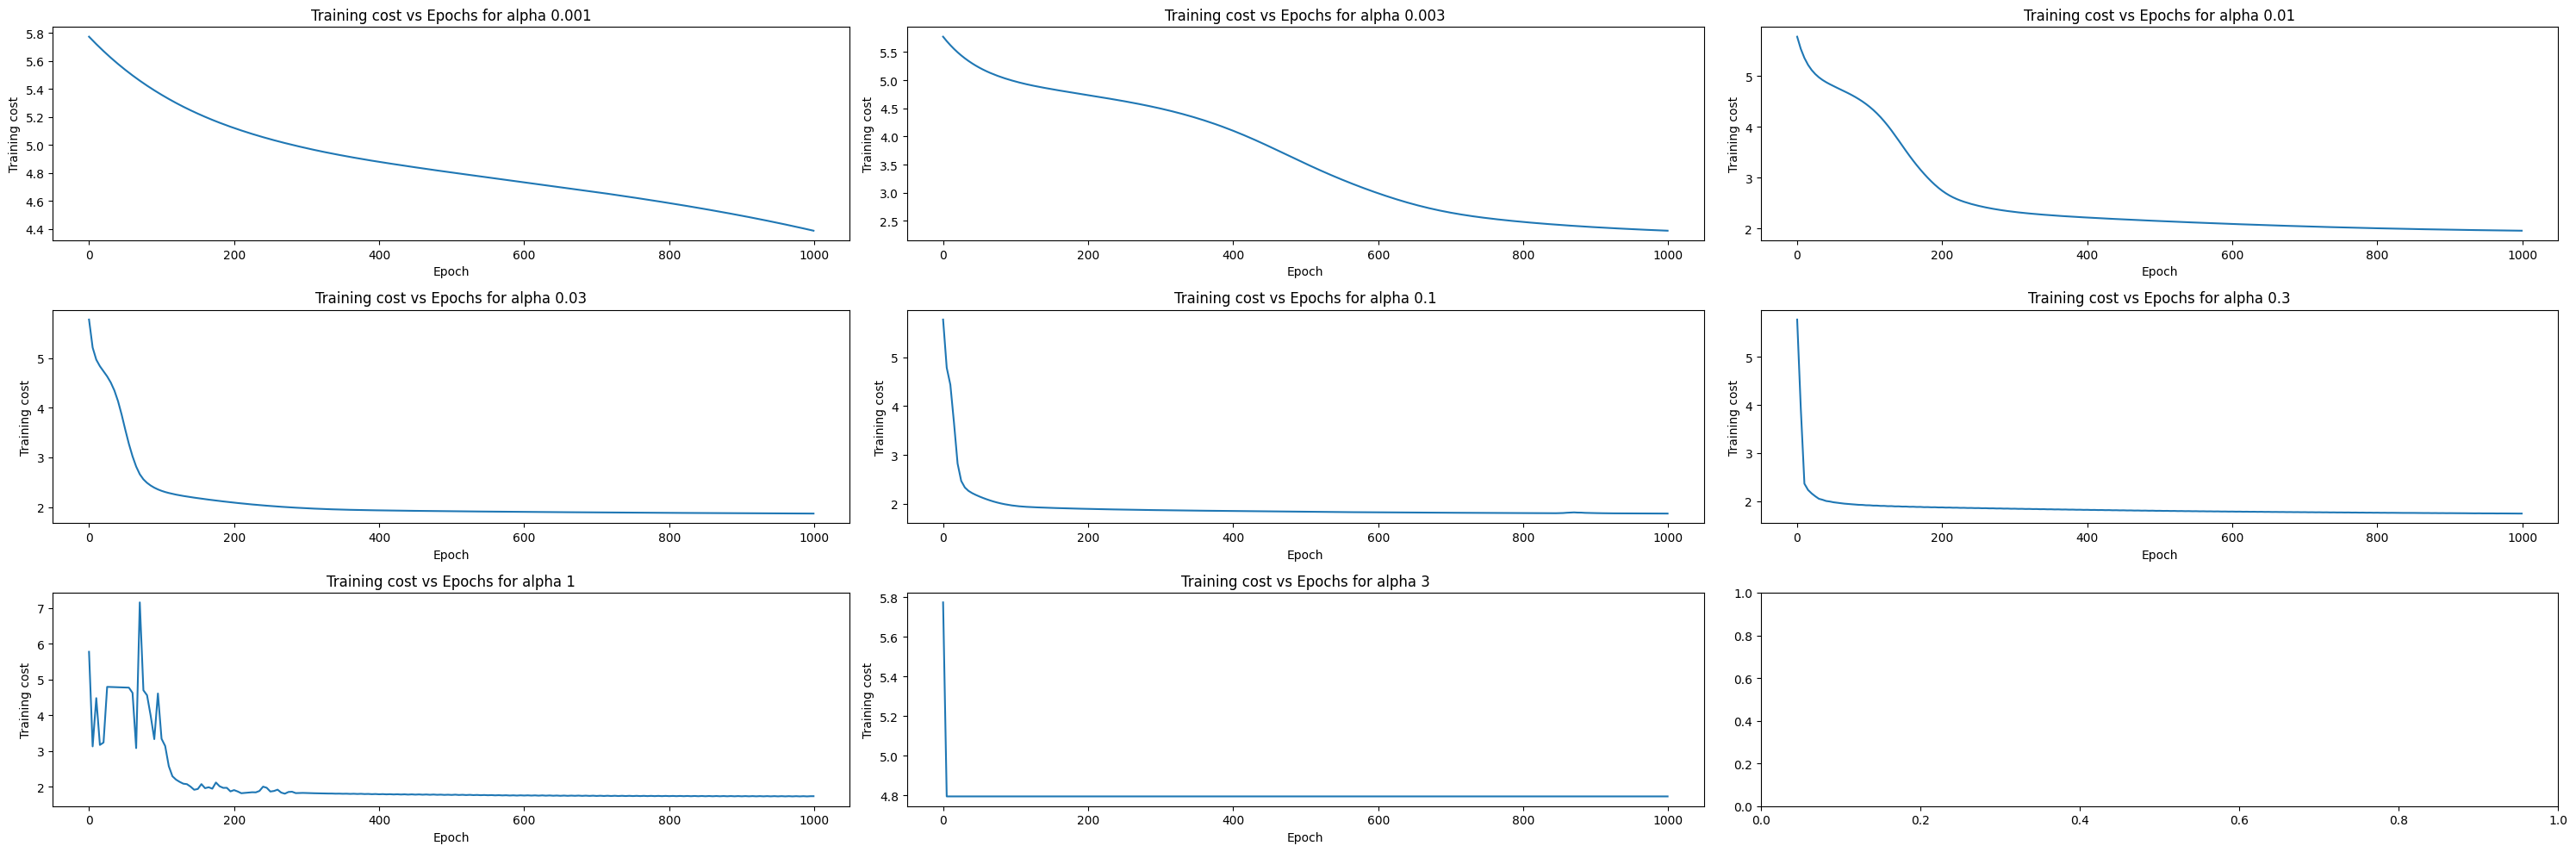

In [524]:
# Look for the best alpha value
# Get initial weights
w_t = np.random.rand(121, 22)
w_p = np.random.rand(1, 9)
b_p = 0
b_t = 0

# Alpha values to try
alphas = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3]

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(30,10))
print
for i in range(len(alphas)):
    # Run gradient descent for each value of alpha with the same initial weights
    # Run gradient descent
    alpha = alphas[i]
    (_, _, _, _, J_train_s) = gradient_descent(
        X=X_train_scaled,
        w_p=w_p,
        w_t=w_t,
        b_p=b_p,
        b_t=b_t,
        Y=Y_train,
        alpha=alpha,
        num_iters=1000,
        J_n=5
    )
    
    epochs = [x[0] for x in J_train_s]
    Js = [y[1] for y in J_train_s]
    
    row = math.floor(i / 3)
    column = i % 3
    
    axs[row][column].plot(epochs, Js)
    axs[row][column].set_xlabel("Epoch")
    axs[row][column].set_ylabel("Training cost")
    axs[row][column].set_title(f"Training cost vs Epochs for alpha {alphas[i]}")


plt.tight_layout()
plt.show()

In [525]:
# Seems that an alpha of 0.3 is the best and it converges at around 1000 epochs. Initialize model with different weights, train with the found hyperparameters above and pick the 
# best model
lowest_J_train = np.inf
new_w_p = np.array([])
new_w_t = np.array([])
new_b_p = np.array([])
new_bt = np.array([]),

for attempts in range(5):
    # Get initial weights
    w_t = np.random.rand(121, 22)
    w_p = np.random.rand(1, 9)
    b_p = 0
    b_t = 0

    # Run gradient descent
    (temp_new_w_p, temp_new_w_t, temp_new_b_p, temp_new_bt, J_train_s) = gradient_descent(
        X=X_train_scaled,
        w_p=w_p,
        w_t=w_t,
        b_p=b_p,
        b_t=b_t,
        Y=Y_train,
        alpha=0.3,
        num_iters=1000
    )
    
    # If cost is lower than lowest found J_train update weights found
    found_J_train = J_train_s[-1][1]
    if found_J_train < lowest_J_train:
        print(f"Lower J_train found {found_J_train}")
        lowest_J_train = found_J_train
        new_w_p = temp_new_w_p
        new_w_t = temp_new_w_t
        new_b_p = temp_new_b_p
        new_bt = temp_new_bt 

Cost at epoch 0/1000 = 9.0763938202591
Cost at epoch 1/1000 = 5.195370831185771
Cost at epoch 2/1000 = 4.9302376869102575
Cost at epoch 3/1000 = 4.811473746569041
Cost at epoch 4/1000 = 4.613238770047815
Cost at epoch 5/1000 = 4.343022396432153
Cost at epoch 6/1000 = 3.960054558804976
Cost at epoch 7/1000 = 3.542980916768666
Cost at epoch 8/1000 = 3.167640807298759
Cost at epoch 9/1000 = 2.8683890292667455
Cost at epoch 10/1000 = 2.6823772354068853
Cost at epoch 11/1000 = 2.558417596218259
Cost at epoch 12/1000 = 2.4551597300455015
Cost at epoch 13/1000 = 2.3646767090706673
Cost at epoch 14/1000 = 2.2864571473783233
Cost at epoch 15/1000 = 2.2237996633318353
Cost at epoch 16/1000 = 2.1778366008763475
Cost at epoch 17/1000 = 2.1445862105299254
Cost at epoch 18/1000 = 2.1199184047825312
Cost at epoch 19/1000 = 2.1008049391215162
Cost at epoch 20/1000 = 2.0855202687044305
Cost at epoch 21/1000 = 2.0725389546418276
Cost at epoch 22/1000 = 2.0608601647697578
Cost at epoch 23/1000 = 2.050265

In [526]:
print(f"Lowest training cost found is {lowest_J_train}")

Lowest training cost found is 1.6992226846698593


In [527]:
def J(
    X: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float,
    Y: npt.NDArray
):
    """ 
    Evaluate model on dataset
    
    Args:
        X (ndarray) - a (m,22,9) array with m examples
        Y (ndarray) - a (m, 2, 1) array with labels for m examples
        w_p (ndarray) - weights for the player section of neural network
        b_p (scalar) - bias for the player section of neural network
        w_t (ndarray) - weights for team section of neural network
        b_t (scalar) - bias for team section of neural network
    """
    J = 0
    m = X.shape[0]
    
    # For each training example
    for i in range(m):
        # Get the prediction
        x_i = X[i]
        y_i = Y[i]
        (y_pred_i, _, _, _) = f_x(
            x_i,
            w_p,
            b_p,
            w_t,
            b_t
        )
        
        # Add loss 
        J += L(y_pred_i, y_i)
        
    J /= m
    print(f"Cost is {J}")
    

In [528]:
J(
    X=X_cv,
    w_p=new_w_p,
    b_p=new_b_p,
    w_t=new_w_t,
    b_t=new_bt,
    Y=Y_cv
)

Cost is 24.015861550672277


In [529]:
def interpret_probabilities(prob):
    """ 
    Function to interpret the returned probabilities by the model
    
    Args:
        prob (ndarray) - array with probabilities for different match results
        
    Returns:
        scores (str) - human readable version of prediction
    """
    predicted = np.argmax(prob)
    home_score = math.floor(predicted / 11)
    away_score = predicted % 11
    return f"{home_score}-{away_score}"

In [530]:
prob = f_x(
    X_cv_scaled[5],
    new_w_p,
    new_b_p,
    new_w_t,
    new_bt
)[0]

predicted_score = interpret_probabilities(prob)
actual_score = interpret_probabilities(Y_cv[5])
print(f"Predicted score is {predicted_score} while actual is {actual_score}")

Predicted score is 2-0 while actual is 5-0


In [531]:
def accuracy_score(y_pred, y_label):
    """ 
    Return the ratio of correct responses across the entire test set.add
    
    Args:
        y_pred (ndarray): (m, 121, 1) array with predictions for each class from the model from the model
        y_label(ndarray): (m, 121, 1) array with the actual labels
        
    Returns:
        accuracy (scalar): ratio of correct responses to all responses
    """
    predictions = np.argmax(y_pred, axis=1)
    actual = np.argmax(y_label, axis=1)
    num_correct = np.sum(predictions == actual)
    return num_correct / y_pred.shape[0]

In [533]:
y_pred = predict(
    X_cv_scaled,
    new_w_p,
    new_b_p,
    new_w_t,
    new_bt
)
accuracy = accuracy_score(y_pred[0], Y_cv)
print(f"Accuracy of model is {accuracy}")

Accuracy of model is 0.2


In [534]:
class PredictionRecall:
    def __init__(self, t_p: int, f_p: int, f_n:int, total: int, label: str):
        """ 
        Return object with prediction recall values
        
        Args:
            label (str): Name of the class
            t_p (int): Total true positive for the given label
            f_p (int): Total false positives for given label
            total (int): Total items with given label
            f_n (int): Total false negatives for given label
        """
        self.total = total
        self.t_p = t_p
        self.f_p = f_p
        self.f_n = f_n
        self.label = label
        
    def __repr__(self):
        return f"{self.label} with t_p: {self.t_p}, f_p: {self.f_p}, f_n: {self.f_n} and total: {self.total}"

def get_precision_recall(y_pred, y_label) -> list[PredictionRecall]:
    """ 
    Returns the precision and recall of the model based on the predictions it has made
    
    Args:
        y_pred (ndarray) - a (m, 121, 1) array with the predictions of the model
        y_label (ndarray) - a (m, 121, 1) array with the actual values
        
    Returns:
        prediction_recall (list) - list of prediction recall values
    """
    predictions = [interpret_probabilities(prob) for prob in y_pred]
    actual = [interpret_probabilities(prob) for prob in y_label]
    all_items = predictions.copy()
    all_items.extend(actual)
    labels = set(all_items)
    
    m = len(actual)
    precisions = []
    
    for label in labels:
        total = 0
        false_positive = 0
        false_negative = 0
        true_positive = 0
        
        for i in range(m):
            entry = actual[i]
            pred = predictions[i]
            
            if entry == label:
                total += 1
                
            if entry == label and pred == entry:
                true_positive += 1
            elif entry != label and pred == label:
                false_positive += 1
        false_negative = total - true_positive
        
        precisions.append(PredictionRecall(
            t_p=true_positive,
            f_p=false_positive,
            f_n=false_negative,
            total=total,
            label=label
        ))
    
    return precisions
    

In [535]:
precisions = get_precision_recall(
    y_pred=np.array([
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ]]),
    y_label=np.array([
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [1],
            [0]
        ],
        [
            [0],
            [0],
            [2]
        ],
        [
            [0],
            [1],
            [0]
        ],
        [
            [0],
            [1],
            [0]
        ],
        [
            [0],
            [0],
            [2]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [1],
            [0]
        ]]),
)
print(precisions)

[0-2 with t_p: 0, f_p: 0, f_n: 2 and total: 2, 0-1 with t_p: 0, f_p: 0, f_n: 4 and total: 4, 0-0 with t_p: 3, f_p: 6, f_n: 0 and total: 3]


In [536]:
def precision_recall(y_pred, y_label):
    """ 
        Print precision recall for model predictions
        
        Args:
            y_pred (ndarray): a (m, 121, 1) array with the predictions of the model
            y_label (ndarray): a (m, 121, 1) array with labels of the model
    """ 
    precisions = get_precision_recall(y_pred=y_pred, y_label=y_label)
    
    # Order precisions by totals
    n = len(precisions)
    for i in range(n):
        swapped = False
        
        for j in range(0, n-i-1):
            # Traverse array from 0 to n - i - 1
            # Swap if the element found is lesser than next element
            if precisions[j].total < precisions[j+1].total:
                precisions[j], precisions[j + 1] = precisions[j + 1], precisions[j]
                swapped = True
        
        if (swapped == False):
            break
    
    
    print(f"    Precision and recall")
    for prec in precisions:
        precision = 0 if prec.f_p + prec.t_p == 0 else (prec.t_p / (prec.f_p + prec.t_p))
        recall = 0 if prec.t_p + prec.f_n == 0 else (prec.t_p) / (prec.t_p + prec.f_n)
        p_1 = 0 if precision == 0 else 1 / precision
        r_1 = 0 if recall == 0 else 1 / recall
        f1_score = 1 / 0.5 * (p_1 + r_1)
        print(f"{prec.label.center(5)}  TP:{prec.t_p}  FP:{prec.f_p}  FN:{prec.f_n}: Prec:{precision:.4f}  Rec:{recall:.4f}  F1:{f1_score:.4f}  Total:{prec.total}")

In [538]:
precision_recall(y_pred=y_pred[0], y_label=Y_cv)

    Precision and recall
 2-0   TP:8  FP:17  FN:12: Prec:0.3200  Rec:0.4000  F1:11.2500  Total:20
 1-0   TP:0  FP:2  FN:14: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:14
 4-0   TP:0  FP:4  FN:13: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:13
 3-0   TP:5  FP:25  FN:6: Prec:0.1667  Rec:0.4545  F1:16.4000  Total:11
 5-0   TP:0  FP:3  FN:6: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:6
 0-0   TP:1  FP:2  FN:4: Prec:0.3333  Rec:0.2000  F1:16.0000  Total:5
 6-0   TP:0  FP:1  FN:1: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:1
 7-0   TP:0  FP:2  FN:0: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:0


In [539]:
# Debugging f_x
print(w_p)

[[0.08954326 0.50258562 0.89740103 0.0061889  0.90205073 0.16384407
  0.93991159 0.49753416 0.70512869]]


In [540]:
print(new_w_p)
print(new_w_p.shape)

[[-0.07140732  0.90313706 -0.76337221  0.62143995 -0.29183727 -0.25250605
   0.42940603  0.60410659 -0.07374129]]
(1, 9)


In [541]:
print(new_b_p)

0.3770823354444975


In [542]:
print(w_t)

[[7.27981430e-01 3.86645266e-02 3.11823777e-01 ... 9.78304691e-02
  1.46172708e-01 9.38698254e-01]
 [4.49783003e-01 5.73453869e-01 4.29792606e-01 ... 6.35537367e-01
  4.30131996e-01 7.50696606e-01]
 [6.69990278e-01 1.45057294e-01 9.43438186e-01 ... 8.09242077e-01
  3.88676813e-01 7.50653822e-01]
 ...
 [5.44624448e-01 8.93284466e-01 9.65615597e-01 ... 9.54800856e-01
  9.60606598e-01 2.53598692e-01]
 [3.61765204e-01 8.47417917e-02 8.87445605e-01 ... 4.23852552e-01
  2.44748614e-01 6.06174663e-01]
 [9.70077583e-01 2.95282451e-01 5.98578583e-01 ... 2.99794809e-01
  1.14294558e-01 2.68870934e-04]]


In [543]:
print(new_w_t)

[[ 0.54099347  1.23867314  0.74173669 ...  1.42382431  1.24735301
   1.08824126]
 [ 0.78317165  0.57995649  0.12452989 ...  0.72700695  0.32382531
   0.33077578]
 [ 0.24741518  0.96997305  0.8518168  ...  0.07552015  0.51720813
   0.45824961]
 ...
 [ 0.40921169  0.68992741  0.33938758 ...  0.78366325  0.711903
  -0.03555382]
 [ 0.37994912  0.09700706  0.17778901 ...  0.84938598  0.59165793
   0.47383449]
 [ 0.68432968  0.09454647  0.2181759  ...  0.28659614  0.53458111
   0.1448968 ]]


In [544]:
print(new_bt)

1.228481602158889e-16


In [ ]:
example = X_cv_scaled[5]
print(example)

[[ 1.99280815e-01 -5.31788336e-01 -7.16858058e-01 -8.06865475e-01
   3.12557687e+00 -6.30667579e-01 -3.47737832e-02 -7.20536566e-01
  -8.80149937e-03]
 [ 1.99280815e-01 -5.31788336e-01 -7.16858058e-01  1.23936397e+00
  -3.19940939e-01 -6.30667579e-01  4.41017644e-01 -5.64417802e-01
   2.75347935e-02]
 [-3.45458399e-01 -5.31788336e-01 -7.16858058e-01  1.23936397e+00
  -3.19940939e-01 -6.30667579e-01 -1.46287399e-01 -2.91209965e-01
  -4.91751582e-02]
 [-3.45458399e-01 -5.31788336e-01  1.39497630e+00 -8.06865475e-01
  -3.19940939e-01 -6.30667579e-01  3.21343863e-02  4.11324473e-01
   1.12319477e-01]
 [ 1.28875924e+00 -5.31788336e-01 -7.16858058e-01  1.23936397e+00
  -3.19940939e-01 -6.30667579e-01  3.22069787e-01 -2.71695120e-01
   7.34796414e-03]
 [ 1.28875924e+00 -5.31788336e-01 -7.16858058e-01  1.23936397e+00
  -3.19940939e-01 -6.30667579e-01  5.22794296e-01 -5.25388111e-01
  -7.26767615e-04]
 [-6.17828006e-01 -5.31788336e-01  1.39497630e+00 -8.06865475e-01
  -3.19940939e-01 -6.3066757

In [545]:
pred, z_t, a_p, z_p = f_x(
    example,
    new_w_p,
    new_b_p,
    new_w_t,
    new_bt
)

In [ ]:
print(pred)
print(interpret_probabilities(pred))
print(interpret_probabilities(Y_cv[5]))

[[1.73716117e-02]
 [7.33140313e-03]
 [3.94223475e-03]
 [1.28780459e-04]
 [5.69301678e-05]
 [5.86382896e-03]
 [1.91466536e-03]
 [7.80879504e-03]
 [2.18215073e-03]
 [3.73316092e-03]
 [2.48893191e-04]
 [1.00099497e-01]
 [5.03014079e-03]
 [8.85576500e-03]
 [2.99545270e-03]
 [1.67656805e-03]
 [3.60884458e-04]
 [1.31220999e-03]
 [5.79794115e-04]
 [2.96937391e-03]
 [3.69115631e-03]
 [6.16539116e-03]
 [2.62270739e-01]
 [2.60529579e-03]
 [5.32501605e-04]
 [1.47559995e-04]
 [4.94307680e-03]
 [1.75911459e-04]
 [8.49554721e-04]
 [3.94591748e-03]
 [6.01103520e-04]
 [1.99443255e-03]
 [3.09738060e-03]
 [1.41360721e-01]
 [6.66120797e-03]
 [3.23602431e-03]
 [7.50841693e-03]
 [2.25065528e-03]
 [5.69255752e-04]
 [3.01801000e-03]
 [3.45262766e-03]
 [1.87917720e-04]
 [4.82658260e-05]
 [1.35638547e-03]
 [1.29230944e-02]
 [2.54218669e-03]
 [4.51589059e-03]
 [2.25992443e-03]
 [7.12528108e-03]
 [4.20716560e-03]
 [2.42061189e-03]
 [2.02916096e-03]
 [4.24345459e-04]
 [2.42713369e-02]
 [2.63890849e-03]
 [7.394187

In [546]:
print(z_t)

[[13.53225665]
 [ 6.34245128]
 [ 7.38039869]
 [ 6.69871841]
 [ 6.43905813]
 [ 6.24849233]
 [ 7.18246799]
 [ 6.38954542]
 [ 7.98757805]
 [ 6.34904066]
 [ 5.05003114]
 [13.36470918]
 [ 6.69169398]
 [ 5.9447007 ]
 [ 6.78649126]
 [ 5.36224418]
 [ 4.31435488]
 [ 7.4060423 ]
 [ 6.57249952]
 [ 4.50799012]
 [ 8.88700723]
 [ 7.14704555]
 [14.15898853]
 [ 6.83056719]
 [ 7.21388976]
 [ 5.28472928]
 [ 8.19062217]
 [ 5.64521135]
 [ 5.43997556]
 [ 6.10400924]
 [ 6.7608563 ]
 [ 6.36485714]
 [ 7.02564744]
 [13.33298512]
 [ 5.78905858]
 [ 6.11696726]
 [ 6.74425912]
 [ 7.47296337]
 [ 4.44220443]
 [ 8.08573569]
 [ 6.03185588]
 [ 8.96461693]
 [ 5.56318353]
 [ 5.90598964]
 [13.19336169]
 [ 4.54348758]
 [ 6.67285987]
 [ 5.84642119]
 [ 7.92523584]
 [ 4.00664469]
 [ 7.52276871]
 [ 4.93340804]
 [ 8.012272  ]
 [ 4.50956774]
 [ 6.60530639]
 [10.91632537]
 [ 4.36919421]
 [ 7.55716468]
 [ 5.14012921]
 [ 3.43157837]
 [ 5.61682434]
 [ 7.86561111]
 [ 5.05196051]
 [ 9.83618198]
 [ 6.96979492]
 [ 5.2525954 ]
 [11.21290

In [547]:
print(a_p)

[[0.        ]
 [1.29898903]
 [1.25639841]
 [0.        ]
 [1.34843967]
 [1.28196981]
 [0.        ]
 [0.        ]
 [0.        ]
 [2.84785755]
 [0.        ]
 [0.        ]
 [0.86223366]
 [0.26900338]
 [0.50668077]
 [0.28559445]
 [0.        ]
 [0.50543358]
 [0.        ]
 [0.        ]
 [0.        ]
 [3.05678413]]


In [ ]:
print(z_p)

[[ 3.21806829]
 [-1.26384607]
 [-1.31634335]
 [ 0.30526488]
 [-0.93502528]
 [-0.99466094]
 [ 0.15826262]
 [ 0.4595878 ]
 [ 0.24654914]
 [-0.81874762]
 [ 0.20970774]
 [ 3.51305161]
 [-1.46092312]
 [-0.90772534]
 [-1.73947452]
 [-0.9706123 ]
 [ 0.61720632]
 [ 0.71228672]
 [ 0.51306479]
 [ 0.62603341]
 [ 0.26043378]
 [-0.37638496]]


In [548]:
print(1 / 121)

0.008264462809917356


In [563]:
def win_prediction_accuracy(y_pred, y_label):
    """ 
    Returns the ratio of accuratey predicted win / loss outcomes
    
    Args:
        y_pred (ndarray) - a (m, 121, 1) with model's predictions
        y_label (ndarray) - a (m, 121, 1) with actual labels
        
    Returns
        win_loss_accuracy (scalar) - ratio of correctly predicted wins / losses
    """
    win = 0
    draw = 1
    loss = 2
    
    predictions = np.argmax(y_pred, axis=1)
    predicted_wins = []
    actual = np.argmax(y_label, axis=1)
    actual_wins = []
    m = len(actual)
    
    for i in range(m):
        predicted_outcome = predictions[i][0]
        predicted_home = math.floor(predicted_outcome / 11)
        predicted_away = predicted_outcome % 11
        predicted_label = win if predicted_home > predicted_away else draw if predicted_home == predicted_away else loss
        predicted_wins.append(predicted_label)
        
        actual_outcome = actual[i][0]
        actual_home = math.floor(actual_outcome / 11)
        actual_away = actual_outcome % 11
        actual_label = win if actual_home > actual_away else draw if actual_home == actual_away else loss
        actual_wins.append(actual_label)
    
    return sum([predicted_wins[i] == actual_wins[i] for i in range(m)]) / m

In [564]:
y_pred_win_test = np.zeros((3, 121, 1))
y_pred_win_test[0][0][0] = 1 # 0 - 0
y_pred_win_test[1][11][0] = 1 # 1 - 0
y_pred_win_test[2][2][0] = 1 # 0 - 2

y_actual_win_test = np.zeros((3, 121, 1))
y_actual_win_test[0][1][0] = 1 # 0 - 1
y_actual_win_test[1][0][0] = 1 # 0 - 0
y_actual_win_test[2][2][0] = 1 # 0 - 2

print(win_prediction_accuracy(y_pred=y_pred_win_test, y_label=y_actual_win_test))

0.3333333333333333


In [565]:
# Checking if model has high bias, high variance or has reached benchmarks
(train_set_pred, _, _, _) = predict(
    X=X_train_scaled,
    w_p=new_w_p,
    b_p=new_b_p,
    w_t=new_w_t,
    b_t=new_bt
)
(cv_set_pred, _, _, _) = predict(
    X=X_cv_scaled,
    w_p=new_w_p,
    b_p=new_b_p,
    w_t=new_w_t,
    b_t=new_bt
)

training_set_accuracy = accuracy_score(train_set_pred, Y_train)
cv_set_accuracy = accuracy_score(cv_set_pred, Y_cv)
training_set_win_pred_accuracy = win_prediction_accuracy(y_pred=train_set_pred, y_label=Y_train)
cv_set_win_pred_accuracy = win_prediction_accuracy(y_pred=cv_set_pred, y_label=Y_cv)

print(f"Benchmark Score Accuracy: 0.18")
print(f"Benchmark Win Accuracy  : 0.7542")
print(f"Training Score Accuracy : {training_set_accuracy}")
print(f"Training Win Accuracy   : {training_set_win_pred_accuracy}")
print(f"CV Set Score Accuracy   : {cv_set_accuracy}")
print(f"CV Set Win Accuracy     : {cv_set_win_pred_accuracy}")

Benchmark Score Accuracy: 0.18
Benchmark Win Accuracy  : 0.7542
Training Score Accuracy : 0.3125
Training Win Accuracy   : 0.8946428571428572
CV Set Score Accuracy   : 0.2
CV Set Win Accuracy     : 0.9142857142857143


In [567]:
# Checking if model has high bias, high variance or has reached benchmarks
(train_set_pred, _, _, _) = predict(
    X=X_train_scaled,
    w_p=new_w_p,
    b_p=new_b_p,
    w_t=new_w_t,
    b_t=new_bt
)
(test_set_pred, _, _, _) = predict(
    X=X_test_scaled,
    w_p=new_w_p,
    b_p=new_b_p,
    w_t=new_w_t,
    b_t=new_bt
)

training_set_accuracy = accuracy_score(train_set_pred, Y_train)
test_set_accuracy = accuracy_score(test_set_pred, Y_test)
training_set_win_pred_accuracy = win_prediction_accuracy(y_pred=train_set_pred, y_label=Y_train)
test_set_win_pred_accuracy = win_prediction_accuracy(y_pred=test_set_pred, y_label=Y_test)

print(f"Benchmark Score Accuracy: 0.18")
print(f"Benchmark Win Accuracy  : 0.7542")
print(f"Training Score Accuracy : {training_set_accuracy}")
print(f"Training Win Accuracy   : {training_set_win_pred_accuracy}")
print(f"Test Set Score Accuracy : {test_set_accuracy}")
print(f"Test Set Win Accuracy   : {test_set_win_pred_accuracy}")

Benchmark Score Accuracy: 0.18
Benchmark Win Accuracy  : 0.7542
Training Score Accuracy : 0.3125
Training Win Accuracy   : 0.8946428571428572
Test Set Score Accuracy : 0.24285714285714285
Test Set Win Accuracy   : 0.9
